In [1]:
# Sel ini menghasilkan TIGA dataset cabang (kota) terpisah untuk Tugas Mandiri Pertemuan 3
import numpy as np
import pandas as pd

kategori_list = ["Elektronik", "Fashion", "Makanan & Minuman", "Kesehatan & Kecantikan", "Rumah Tangga"]
metode_bayar_list = ["Transfer Bank", "E-Wallet", "COD", "Kartu Kredit"]
tanggal_range = pd.date_range("2026-08-01", "2026-08-31", freq="D")

cabang_kota = {"Magelang": 101, "Yogyakarta": 202, "Semarang": 303}

for kota, seed in cabang_kota.items():
    np.random.seed(seed)  # seed berbeda tiap kota agar datanya bervariasi, namun tetap konsisten/reproducible
    n = 200
    data_cabang = {
        "order_id": [f"{kota[:3].upper()}-{2000 + i}" for i in range(n)],
        "tanggal": np.random.choice(tanggal_range, size=n),
        "kategori": np.random.choice(kategori_list, size=n, p=[0.25, 0.25, 0.20, 0.15, 0.15]),
        "unit_terjual": np.random.randint(1, 8, size=n),
        "harga_satuan": np.random.choice([25000, 50000, 75000, 100000, 150000, 250000], size=n),
        "metode_pembayaran": np.random.choice(metode_bayar_list, size=n),
    }
    df_cabang = pd.DataFrame(data_cabang)
    df_cabang["kota"] = kota
    nama_file = f"transaksi_{kota.lower()}.csv"
    df_cabang.to_csv(nama_file, index=False)
    print(f"Berkas '{nama_file}' berhasil dibuat: {df_cabang.shape[0]} baris")

print("\nKetiga berkas CSV cabang siap digunakan untuk Tugas Mandiri.")

Berkas 'transaksi_magelang.csv' berhasil dibuat: 200 baris
Berkas 'transaksi_yogyakarta.csv' berhasil dibuat: 200 baris
Berkas 'transaksi_semarang.csv' berhasil dibuat: 200 baris

Ketiga berkas CSV cabang siap digunakan untuk Tugas Mandiri.


In [2]:
# membangun struktur direktori HDFS
!hdfs dfs -mkdir -p /user/uwah/ecommerce/raw
!hdfs dfs -mkdir -p /user/uwah/ecommerce/processed

# verifikasi struktur yang terbentuk
!hdfs dfs -ls /user/uwah/ecommerce

Found 2 items
drwxr-xr-x   - uwah supergroup          0 2026-09-08 15:11 /user/uwah/ecommerce/processed
drwxr-xr-x   - uwah supergroup          0 2026-09-08 15:11 /user/uwah/ecommerce/raw


In [6]:
# Unggah data mentah ke HDFS
# unggah ketiga cv ke ke direktori raw
!hdfs dfs  -put -f transaksi_magelang.csv /user/uwah/ecommerce/raw/
!hdfs dfs  -put -f transaksi_yogyakarta.csv /user/uwah/ecommerce/raw/
!hdfs dfs  -put -f transaksi_semarang.csv /user/uwah/ecommerce/raw/

In [14]:
#
df_magelang = pd.read_csv("transaksi_magelang.csv")
df_magelang.head()

,order_id,tanggal,kategori,unit_terjual,harga_satuan,metode_pembayaran,kota
0,MAG-2000,2026-08-12,Fashion,1,50000,Transfer Bank,Magelang
1,MAG-2001,2026-08-18,Elektronik,7,25000,COD,Magelang
2,MAG-2002,2026-08-07,Elektronik,7,25000,E-Wallet,Magelang
3,MAG-2003,2026-08-24,Rumah Tangga,6,25000,COD,Magelang
4,MAG-2004,2026-08-30,Fashion,7,100000,Transfer Bank,Magelang


In [15]:
#
df_semarang = pd.read_csv("transaksi_semarang.csv")
df_semarang.head()

,order_id,tanggal,kategori,unit_terjual,harga_satuan,metode_pembayaran,kota
0,SEM-2000,2026-08-28,Elektronik,3,100000,E-Wallet,Semarang
1,SEM-2001,2026-08-29,Kesehatan & Kecantikan,4,25000,Transfer Bank,Semarang
2,SEM-2002,2026-08-19,Rumah Tangga,1,25000,COD,Semarang
3,SEM-2003,2026-08-02,Makanan & Minuman,2,75000,E-Wallet,Semarang
4,SEM-2004,2026-08-05,Elektronik,6,25000,Transfer Bank,Semarang


In [16]:
#
df_yogyakarta = pd.read_csv("transaksi_yogyakarta.csv")
df_yogyakarta.head()

,order_id,tanggal,kategori,unit_terjual,harga_satuan,metode_pembayaran,kota
0,YOG-2000,2026-08-20,Fashion,5,250000,E-Wallet,Yogyakarta
1,YOG-2001,2026-08-24,Fashion,4,150000,Kartu Kredit,Yogyakarta
2,YOG-2002,2026-08-29,Rumah Tangga,4,100000,E-Wallet,Yogyakarta
3,YOG-2003,2026-08-13,Fashion,7,250000,E-Wallet,Yogyakarta
4,YOG-2004,2026-08-09,Elektronik,7,75000,COD,Yogyakarta


In [8]:
# Membaca Kembali dan Menggabungkan Data dari HDFS
import pandas as pd
import io
import subprocess

files = ["transaksi_magelang.csv", "transaksi_yogyakarta.csv", "transaksi_semarang.csv"]
list_df = []

# Membaca data langsung dari HDFS menggunakan perintah cat
for f in files:
    path_hdfs = f"/user/uwah/ecommerce/raw/{f}"
    content = subprocess.check_output(["hdfs", "dfs", "-cat", path_hdfs]).decode('utf-8')
    df = pd.read_csv(io.StringIO(content))
    list_df.append(df)

# Menggabungkan ketiga DataFrame menjadi satu
df_gabungan = pd.concat(list_df, ignore_index=True)

# Menampilkan jumlah transaksi per kota
print("Jumlah transaksi per kota:")
print(df_gabungan['kota'].value_counts())

Jumlah transaksi per kota:
kota
Magelang      200
Yogyakarta    200
Semarang      200
Name: count, dtype: int64


In [17]:
df_gabungan

,order_id,tanggal,kategori,unit_terjual,harga_satuan,metode_pembayaran,kota,total_pendapatan
0,MAG-2000,2026-08-12,Fashion,1,50000,Transfer Bank,Magelang,50000
1,MAG-2001,2026-08-18,Elektronik,7,25000,COD,Magelang,175000
2,MAG-2002,2026-08-07,Elektronik,7,25000,E-Wallet,Magelang,175000
3,MAG-2003,2026-08-24,Rumah Tangga,6,25000,COD,Magelang,150000
4,MAG-2004,2026-08-30,Fashion,7,100000,Transfer Bank,Magelang,700000
...,...,...,...,...,...,...,...,...
595,SEM-2195,2026-08-31,Rumah Tangga,6,75000,Transfer Bank,Semarang,450000
596,SEM-2196,2026-08-15,Kesehatan & Kecantikan,5,75000,Transfer Bank,Semarang,375000
597,SEM-2197,2026-08-01,Makanan & Minuman,4,75000,E-Wallet,Semarang,300000
598,SEM-2198,2026-08-05,Fashion,7,25000,Transfer Bank,Semarang,175000


In [9]:
# mengolah dan download hasil ke directori
# 1. Menambahkan kolom total_pendapatan
df_gabungan['total_pendapatan'] = df_gabungan['unit_terjual'] * df_gabungan['harga_satuan']

# 2. Membuat tabel ringkasan (groupby) per kota dan per kategori
df_ringkasan = df_gabungan.groupby(['kota', 'kategori'])['total_pendapatan'].sum().reset_index()

# 3. Menyimpan kedua hasil ke disk lokal VM
df_gabungan.to_csv("data_gabungan_bersih.csv", index=False)
df_ringkasan.to_csv("ringkasan_kota_kategori.csv", index=False)

print("File hasil olahan berhasil disimpan di disk lokal VM.")

File hasil olahan berhasil disimpan di disk lokal VM.


In [18]:
# menampilkan hanya kolom total pendapatan
df_gabungan['total_pendapatan']

0       50000
1      175000
2      175000
3      150000
4      700000
        ...  
595    450000
596    375000
597    300000
598    175000
599    200000
Name: total_pendapatan, Length: 600, dtype: int64

In [20]:
# menampilkan seluruh tabel beserta kolom total_pendapatan
df_gabungan.head()

,order_id,tanggal,kategori,unit_terjual,harga_satuan,metode_pembayaran,kota,total_pendapatan
0,MAG-2000,2026-08-12,Fashion,1,50000,Transfer Bank,Magelang,50000
1,MAG-2001,2026-08-18,Elektronik,7,25000,COD,Magelang,175000
2,MAG-2002,2026-08-07,Elektronik,7,25000,E-Wallet,Magelang,175000
3,MAG-2003,2026-08-24,Rumah Tangga,6,25000,COD,Magelang,150000
4,MAG-2004,2026-08-30,Fashion,7,100000,Transfer Bank,Magelang,700000


In [21]:
# menampilkan ringkasan statistik total_pendapatan
df_gabungan['total_pendapatan'].describe()

count    6.000000e+02
mean     4.716667e+05
std      4.347410e+05
min      2.500000e+04
25%      1.500000e+05
50%      3.000000e+05
75%      6.000000e+05
max      1.750000e+06
Name: total_pendapatan, dtype: float64

In [12]:
# membuat folder tujuan di HDFS
!hdfs dfs -mkdir -p /user/uwah/ecommerce/processed/
# mengunggah kedua file hasil olahan ke folder processed di HDFS
!hdfs dfs -put -f data_gabungan_bersih.csv /user/uwah/ecommerce/processed/
!hdfs dfs -put -f ringkasan_kota_kategori.csv /user/uwah/ecommerce/processed/

# verifikasi isi direktori processed
!hdfs dfs -ls -h /user/uwah/ecommerce/processed

Found 2 items
-rw-r--r--   1 uwah supergroup     40.3 K 2026-09-08 16:05 /user/uwah/ecommerce/processed/data_gabungan_bersih.csv
-rw-r--r--   1 uwah supergroup        530 2026-09-08 16:05 /user/uwah/ecommerce/processed/ringkasan_kota_kategori.csv


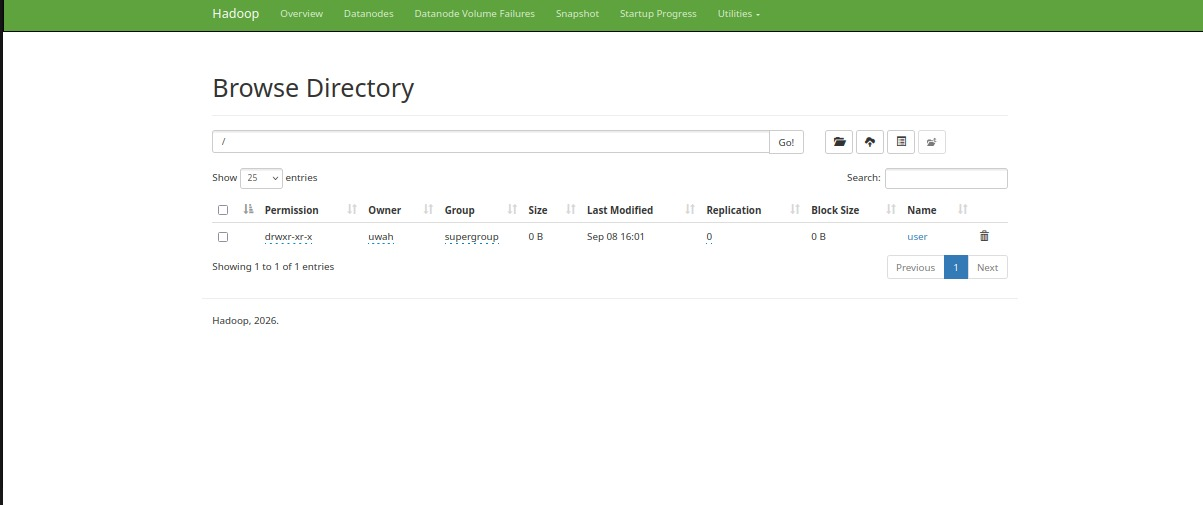

In [3]:
# ss Halaman NameNode Web UI
from IPython.display import Image, display
display(Image(filename='sshalnamenode.jpeg'))

# refleksi 
Memisahkan folder data mentah(raw) dan data olahan(processed) di HDFS sangat penting karena bertindak seperti membuat cadangan aman untuk  file kita. Data mentah di folder raw ini adalah file asli dari berbagai cabang yang tidak boleh diubah atau diotak atik. Jika suatu saaat nanti kita salah menghitung rumus atau data data yang terhapus saat proses pembersihan, kita tidak perlu panik karena file asli masih tersimpan dan bisa diproses ulang dari awal.
Selain, pemisahan ini membuat susunan folder di HDFS menjadi rapi dan tidak berantakan. Tim yang butuh data bersih untuk membuat laporan(Data Analis atau BI) bisa langsung mengambil file dari folder processed tanpa pusing memilih mana file yang sudah rapi dann mana yang belum. Dari segi keamanan, kita juga bisa mengatur agar folder raw hanya boleh diakses oleh orang tertentu saja,  sehingga mencegah file penting terhapus secara tidak sengaja maupun sengaja oleh pihak lain.